In [2]:
!pip install datasets
!pip install textblob


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from textblob import TextBlob

# 1) Load dataset from HuggingFace

In [ ]:

ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds['train'].to_pandas()
df = df[df['language'] == 'en'].reset_index(drop=True)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (28261, 16)

Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [5]:
# Basic info
print("Data Types:")
print(df.dtypes)


Data Types:
subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object


# 2) Missing values

Missing Values Summary
         Missing Count  Missing %
tag_8            26653  94.310180
tag_7            24562  86.911291
tag_6            20353  72.017975
tag_5            11960  42.319805
version          11923  42.188882
subject           3639  12.876402
tag_4             2584   9.143342
tag_3              113   0.399844
tag_2               16   0.056615
answer               6   0.021231
body                 1   0.003538


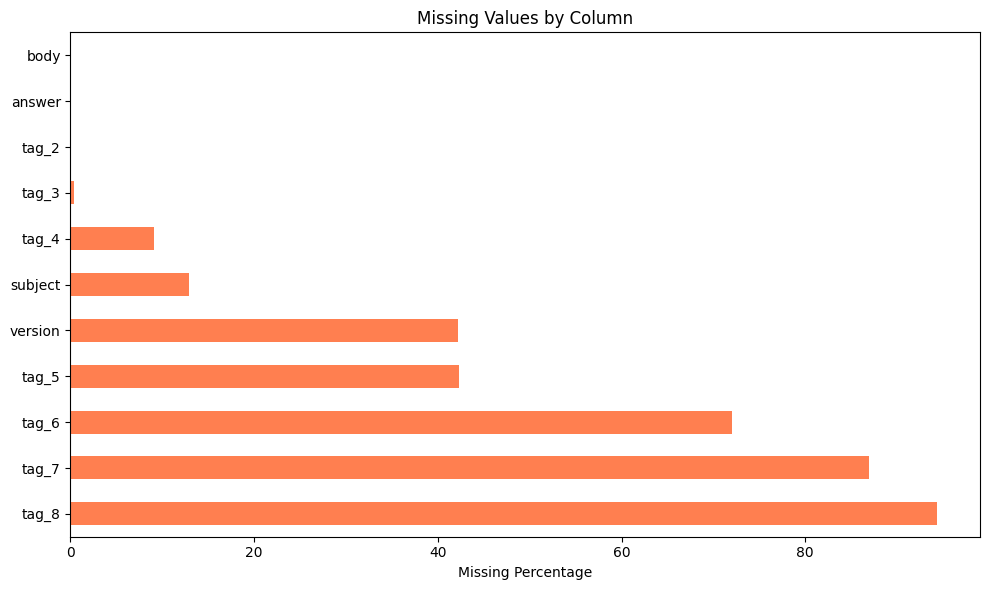

In [ ]:

missing = df.isnull().sum()
missingpercent = (missing / len(df)) * 100

missingdata = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missingpercent
}).sort_values(by='Missing %', ascending=False)

print("Missing Values Summary")
print(missingdata[missingdata['Missing Count'] > 0])

# Visualize
plt.figure(figsize=(10, 6))
missingdata[missingdata['Missing Count'] > 0]['Missing %'].plot(kind='barh', color='coral')
plt.title('Missing Values by Column')
plt.xlabel('Missing Percentage')
plt.tight_layout()
plt.show()

# 3) Collect all tags

TOP 20 TAGS
Tech Support: 14444
IT: 14052
Performance: 11423
Feedback: 8724
Documentation: 7657
Bug: 7534
Security: 6602
Feature: 5792
Disruption: 4249
Outage: 3594
Technical: 3531
Network: 3251
Product: 2764
Sales: 2610
Resolution: 2414
Guidance: 1997
Recovery: 1773
Billing: 1738
Crash: 1726
Integration: 1399


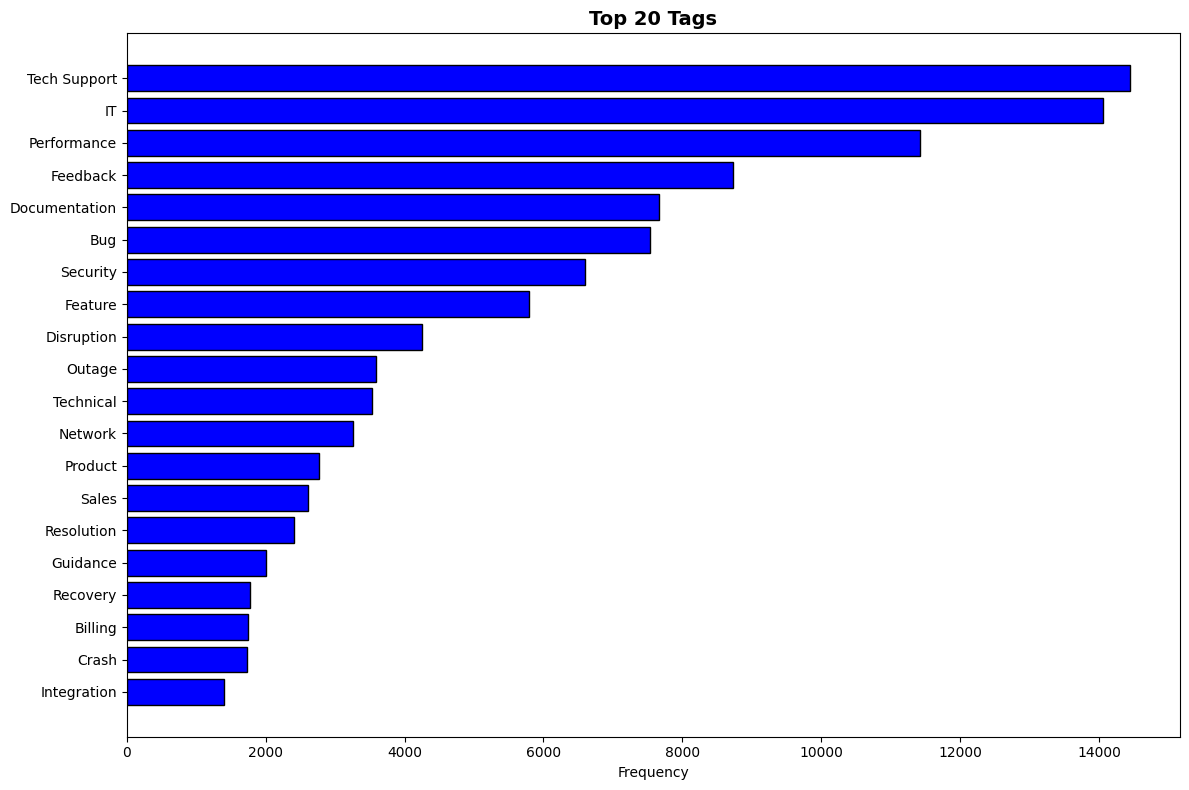

In [ ]:

tags = []
tagcol = [f'tag_{i}' for i in range(1, 9)]

for col in tagcol:
    tags.extend(df[col].dropna().tolist())

tagcount = Counter(tags)
tagtop = tagcount.most_common(20)

print("TOP 20 TAGS")
for tag, count in tagtop:
    print(f"{tag}: {count}")

plt.figure(figsize=(12, 8))
plot, counts_plot = zip(*tagtop)
plt.barh(range(len(plot)), counts_plot, color='blue', edgecolor='black')
plt.yticks(range(len(plot)), plot)
plt.xlabel('Frequency')
plt.title('Top 20 Tags', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4) Tag coverage analysis

In [ ]:

print("TAG COVERAGE")
for col in tagcol:
    ncount = (df[col] == 'None').sum() + df[col].isnull().sum()
    filled_count = len(df) - ncount
    print(f"{col}: {filled_count} filled ({filled_count/len(df)*100:.1f}%), {ncount} missing/None ({ncount/len(df)*100:.1f}%)")

TAG COVERAGE
tag_1: 28261 filled (100.0%), 0 missing/None (0.0%)
tag_2: 28245 filled (99.9%), 16 missing/None (0.1%)
tag_3: 28148 filled (99.6%), 113 missing/None (0.4%)
tag_4: 25677 filled (90.9%), 2584 missing/None (9.1%)
tag_5: 16301 filled (57.7%), 11960 missing/None (42.3%)
tag_6: 7908 filled (28.0%), 20353 missing/None (72.0%)
tag_7: 3699 filled (13.1%), 24562 missing/None (86.9%)
tag_8: 1608 filled (5.7%), 26653 missing/None (94.3%)


# 5) Add text length features

TEXT LENGTH STATISTICS

Character count:
count    28261.000000
mean       371.265843
std        202.882721
min          4.000000
25%        203.000000
50%        365.000000
75%        533.000000
max       1793.000000
Name: text_length, dtype: float64

Word count:
count    28261.000000
mean        55.352677
std         31.249665
min          1.000000
25%         30.000000
50%         54.000000
75%         79.000000
max        272.000000
Name: word_count, dtype: float64


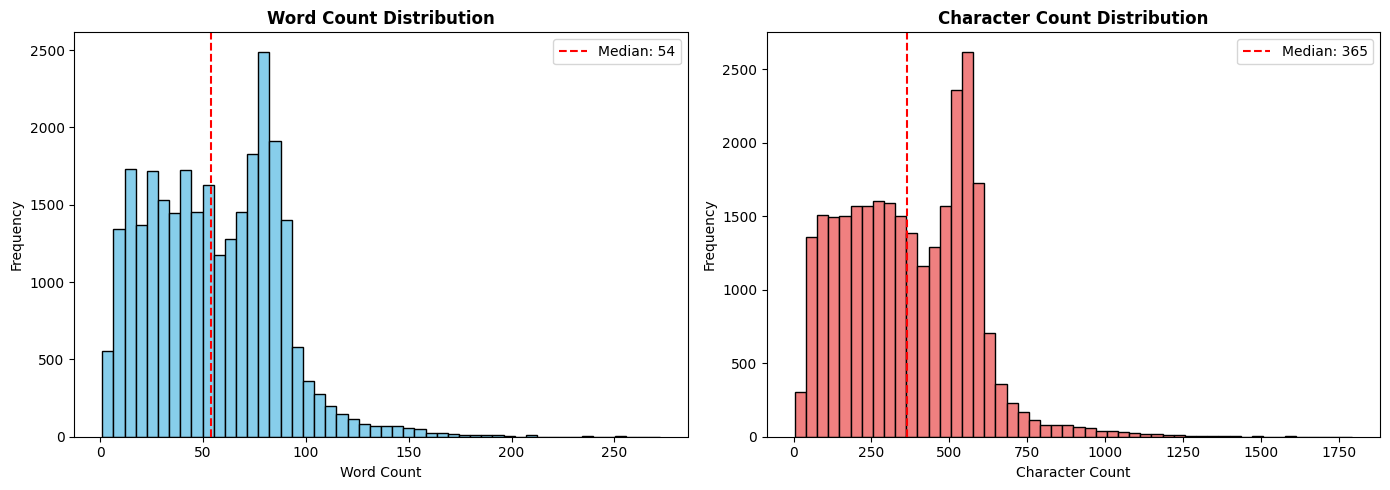

In [ ]:

df['text_length'] = df['body'].astype(str).apply(len)
df['word_count'] = df['body'].astype(str).apply(lambda x: len(x.split()))

print("TEXT LENGTH STATISTICS")
print("\nCharacter count:")
print(df['text_length'].describe())
print("\nWord count:")
print(df['word_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0].legend()

axes[1].hist(df['text_length'], bins=50, edgecolor='black', color='lightcoral')
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 6) Type vs Priority


=== TYPE vs PRIORITY ===
priority  high   low  medium
type                        
Change    1160   607    1223
Incident  4834  2080    4299
Problem   2172  1245    2478
Request   2751  1842    3570


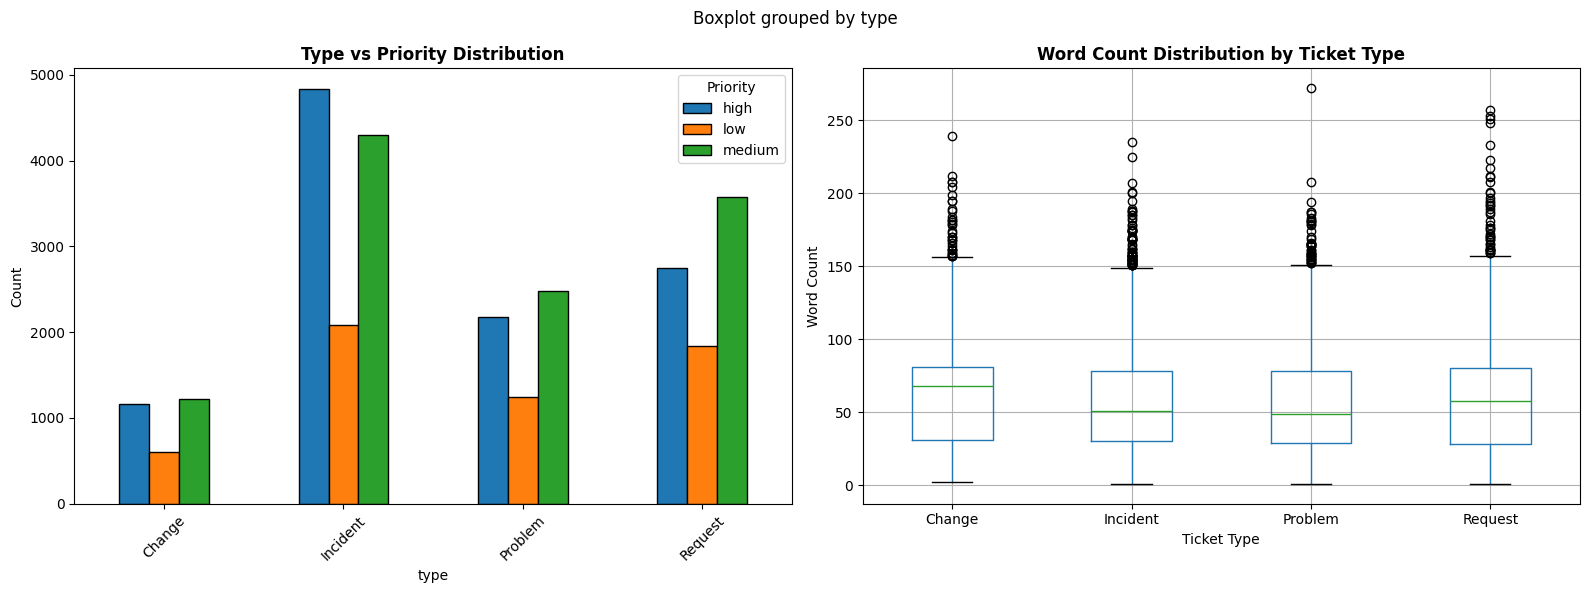

In [ ]:

print("\nTYPE vs PRIORITY ")
type_priority = pd.crosstab(df['type'], df['priority'])
print(type_priority)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
type_priority.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Type vs Priority Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Priority')
df.boxplot(column='word_count', by='type', ax=axes[1])
axes[1].set_title('Word Count Distribution by Ticket Type', fontweight='bold')
axes[1].set_xlabel('Ticket Type')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

# 7) Language vs type

In [11]:
print("LANGUAGE vs TYPE")
languagetyp = pd.crosstab(df['language'], df['type'])
print(languagetyp)
if len(df['language'].unique()) > 1:
    plt.figure(figsize=(10, 6))
    languagetyp.plot(kind='bar', edgecolor='black')
    plt.title('Language vs Type Distribution', fontweight='bold')
    plt.ylabel('Count')
    plt.legend(title='Type')
    plt.tight_layout()
    plt.show()

LANGUAGE vs TYPE
type      Change  Incident  Problem  Request
language                                    
en          2990     11213     5895     8163
